### Iteration - 6 (PowerTransformer)


In [0]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import PowerTransformer
from sklearn.metrics import silhouette_score, silhouette_samples


df_user_behavior = spark.table('workspace.spotify.spotify_user_behavior').toPandas()

CLUSTER_FEATURES_V6 = [
    'daily_listening_minutes',  # usage intensity
    'sessions_per_day',         # frequency
    'days_active_last_30',      # consistency
    'avg_session_minutes',      # depth
    'skip_rate',                # content friction
    'liked_songs_pct',          # positive engagement
    'ads_skipped_pct'           # monetization friction
]

In [0]:
base = df_user_behavior[['user_id'] + CLUSTER_FEATURES_V6].copy()
before_rows = len(base)
base = base.dropna(subset = CLUSTER_FEATURES_V6)
after_rows = len(base)

if before_rows != after_rows:
    print(f' Dropped {before_rows - after_rows} rows due to nulls')

In [0]:
k =4 # 3-4 clusters are consider for business personas

In [0]:
X6= base[CLUSTER_FEATURES_V6].copy()

pt = PowerTransformer(
    method = 'yeo-johnson',  # This method is best for clustering. not classification
    standardize = True
)

X6_scaled = pt.fit_transform(X6)
X6 = pd.DataFrame(
    X6_scaled,
    columns = CLUSTER_FEATURES_V6,
    index = base.index
)

km6= KMeans(
    n_clusters = k,
    random_state = 42,
    n_init = 20,   # more stable than sklearn default (often 10)
    max_iter = 300
)

In [0]:
labels6 = km6.fit_predict(X6)
inertia6 = km6.inertia_

sil_avg_6= silhouette_score(X6, labels6)
base_iter6 = base.copy()
base_iter6['cluster']= labels6
print(f'Inertia: {round(inertia6,2)}')
print(f' Silhoutte: {round(sil_avg_6,2)}')
sizes6 = base_iter6['cluster'].value_counts().sort_index()
sizes6

Inertia: 471012.28
 Silhoutte: 0.17


cluster
0    17925
1    37460
2    26899
3    25716
Name: count, dtype: int64

In [0]:
means6= (
    base_iter6.groupby('cluster')[CLUSTER_FEATURES_V6].mean().round(3))

In [0]:
profile6 = means6.copy()
profile6.insert(0, 'cluster_size', sizes6)
display(profile6)

cluster_size,daily_listening_minutes,sessions_per_day,days_active_last_30,avg_session_minutes,skip_rate,liked_songs_pct,ads_skipped_pct
17925,86.61048817384024,2.687,21.964757185857124,32.397983758099784,0.289,0.30651889125587223,0.579770517621438
37460,14.973016377744084,1.08,20.362217632082945,14.510435281627359,0.411,0.24786355571743374,0.48386585318339165
26899,45.741404622040605,1.0,24.744633491183652,45.741404622040605,0.285,0.3930298131557334,0.4828126422595701
25716,46.639261933723,1.0,18.060951615033378,46.63598136376379,0.269,0.21611907565971603,0.6698472337614557


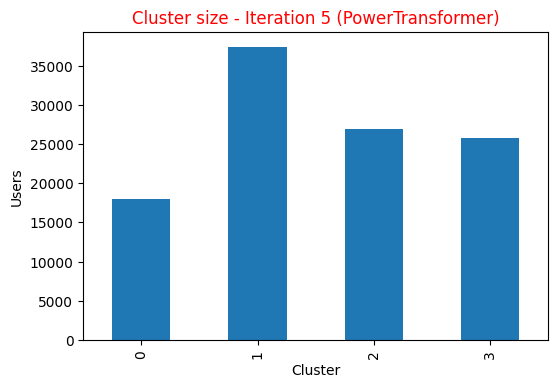

In [0]:
import matplotlib.pyplot as plt
plt.figure(figsize = (6,4))

base_iter6['cluster'].value_counts().sort_index().plot(kind= 'bar')
plt.title('Cluster size - Iteration 5 (PowerTransformer)', color = 'red')
plt.xlabel('Cluster')
plt.ylabel('Users')
plt.show()

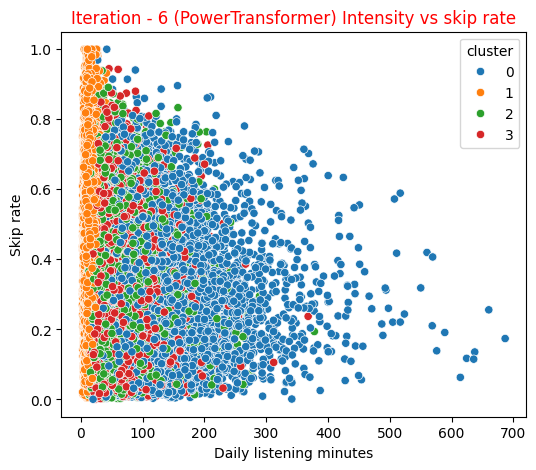

In [0]:
# scatter plot (No PCA)

# intensity vs skip
import seaborn as sns

plt.figure(figsize= (6,5))
sns.scatterplot(
    data = base_iter6,
    x = 'daily_listening_minutes',
    y = 'skip_rate',
    hue = 'cluster',
    palette = 'tab10'
)

plt.title('Iteration - 6 (PowerTransformer) Intensity vs skip rate', color = 'red')
plt.xlabel('Daily listening minutes')
plt.ylabel('Skip rate')
plt.show()

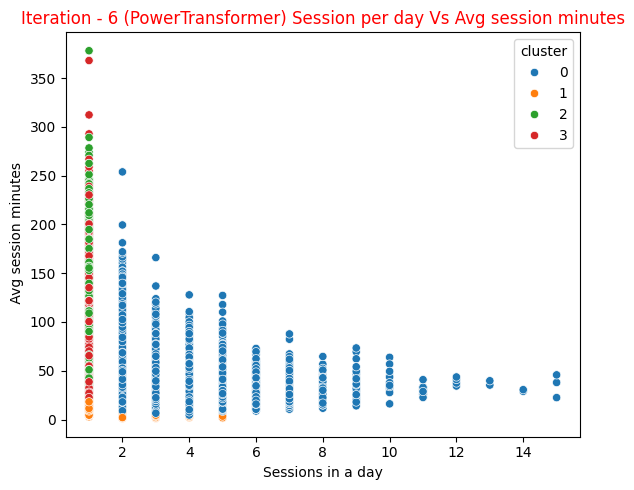

In [0]:
# frequency vs Session depth

plt.figure(figsize= (6,5))

sns.scatterplot(
    data = base_iter6,
    x = 'sessions_per_day',
    y= 'avg_session_minutes',
    hue = 'cluster',
    palette = 'tab10'
)

plt.title('Iteration - 6 (PowerTransformer) Session per day Vs Avg session minutes', color = 'red')
plt.xlabel('Sessions in a day')
plt.ylabel(' Avg session minutes')
plt.tight_layout()
plt.show()

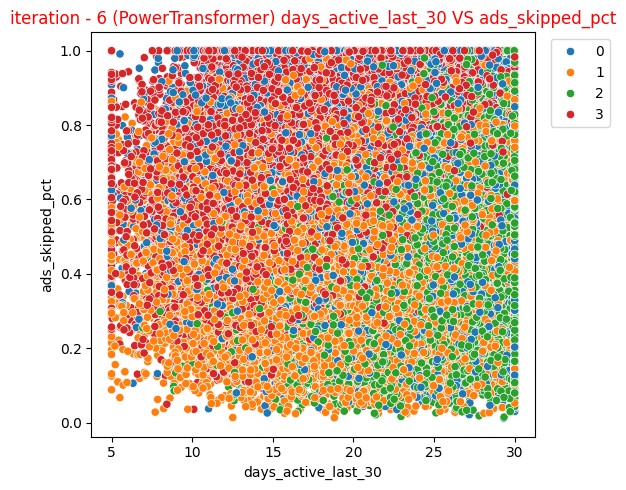

In [0]:
# consistance vs Ad friction

plt.figure(figsize= (6,5))

sns.scatterplot(
    data = base_iter6,
    x = 'days_active_last_30',
    y= 'ads_skipped_pct',
    hue = 'cluster',
    palette = 'tab10'
)

plt.title('iteration - 6 (PowerTransformer) days_active_last_30 VS ads_skipped_pct', color = 'red')
plt.legend(bbox_to_anchor = (1.02, 1))
plt.tight_layout()
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

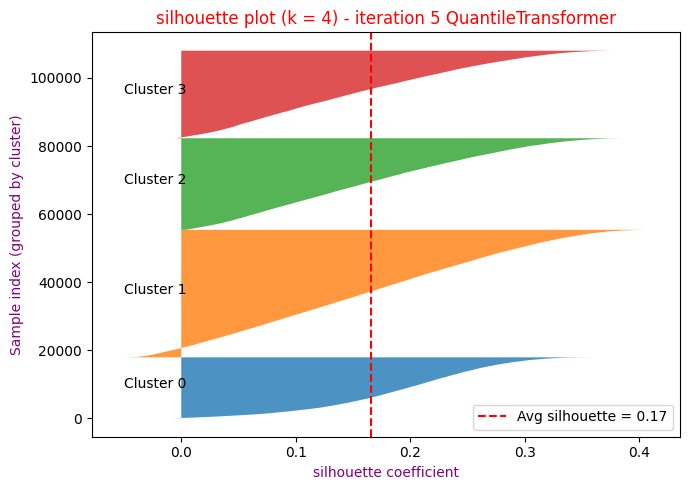

In [0]:
# silhouette Plot

sil_values_6 = silhouette_samples(X6, labels6)
sil_avg_6 = silhouette_score(X6, labels6)
plt.figure(figsize= (7,5))

y_lower = 0

vals0 = sil_values_6[labels6 == 0]
vals0.sort()
size0 = vals0.shape[0]

y_upper = y_lower + size0

plt.fill_betweenx(
    np.arange(y_lower, y_upper),    # vertical span
    0,                              # left boundary (silhoutte = 0)
    vals0,                          # right boundary (actual silhoutte values)
    alpha = 0.8
)
plt.text(
    -0.05,
    y_lower + 0.5 * size0,  # slightly left of zero
    'Cluster 0'             # vertically centered
)

y_lower = y_upper

# Cluster 1
vals1 = sil_values_6[labels6==1]
vals1.sort()
size1 = vals1.shape[0]

y_upper = y_lower + size1

plt.fill_betweenx(
    np.arange(y_lower, y_upper),
    0,
    vals1,
    alpha = 0.8
    )
plt.text(-0.05,
         y_lower + 0.5 * size1, 'Cluster 1')

y_lower = y_upper

# cluster 2
vals2 = sil_values_6[labels6 == 2]
vals2.sort()

size2 = vals2.shape[0]
y_upper = y_lower + size2
plt.fill_betweenx(np.arange(y_lower, y_upper), 0, vals2, alpha = 0.8)
plt.text(-0.05, y_lower + 0.5 * size2, 'Cluster 2')

y_lower = y_upper

# cluster 3
vals3 = sil_values_6[labels6 == 3]
vals3.sort()
size3 = vals3.shape[0]
y_upper = y_lower + size3
plt.fill_betweenx(np.arange(y_lower, y_upper), 0, vals3, alpha = 0.8)
plt.text(-0.05, y_lower + 0.5 * size3, 'Cluster 3')

y_lower = y_upper

plt.axvline(
    x= sil_avg_6,
    color = 'red',
    linestyle = '--',
    label =f"Avg silhouette = {sil_avg_6:.2f}"
)

plt.title('silhouette plot (k = 4) - iteration 5 QuantileTransformer', color = 'red')
plt.xlabel('silhouette coefficient', color = 'purple')
plt.ylabel('Sample index (grouped by cluster)', color = 'purple')
plt.legend()
plt.tight_layout()
plt.show